# OpenCV Optical Flow & Folding Correction

Uses OpenCV dense optical flow methods to compute displacement fields
between image pairs, then corrects folding with DVFopt.

Optical flow is not designed for medical image registration, but it
produces dense displacement fields that frequently contain folding
(negative Jacobian determinants) â€” making it a good stress test.

Methods tested:

1. **Farneback** â€” polynomial expansion, fast, often folds
2. **TV-L1** â€” total variation L1, better edge-preserving
3. **DIS (Dense Inverse Search)** â€” real-time optical flow

**Requirements:**
```
pip install opencv-python-headless
```

In [1]:
import time
import importlib

import numpy as np
import matplotlib.pyplot as plt

from dvfopt import jacobian_det2D, iterative_parallel
from dvfopt.viz import (
    plot_grid_before_after,
    plot_checkerboard_before_after,
    plot_neg_jdet_neighborhoods,
)

HAS_CV2 = importlib.util.find_spec("cv2") is not None
print(f"OpenCV: {'available' if HAS_CV2 else 'MISSING â€” pip install opencv-python-headless'}")

OpenCV: available


## Configuration

In [2]:
IMAGE_SIZE = 64
JDET_THRESHOLD = 0.01

# Real image paths (set both to use real data instead of synthetic)
FIXED_IMAGE_PATH = None
MOVING_IMAGE_PATH = None

## Generate (or load) test images

We use images with enough structural difference to produce large,
fold-inducing displacements.

Generated synthetic 64x64 test images


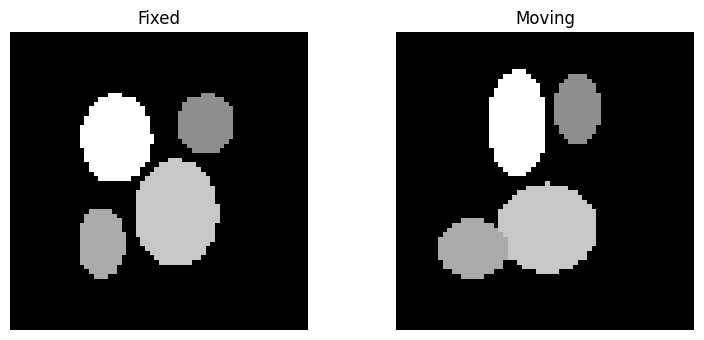

In [3]:
def make_test_image(size, shapes):
    img = np.zeros((size, size), dtype=np.float32)
    yy, xx = np.mgrid[0:size, 0:size].astype(np.float32)
    for cy, cx, ry, rx, intensity in shapes:
        mask = ((yy - cy) / ry) ** 2 + ((xx - cx) / rx) ** 2 <= 1.0
        img[mask] = intensity
    return img


if FIXED_IMAGE_PATH is not None and MOVING_IMAGE_PATH is not None:
    import cv2
    fixed_np = cv2.imread(FIXED_IMAGE_PATH, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
    moving_np = cv2.imread(MOVING_IMAGE_PATH, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
    IMAGE_SIZE = fixed_np.shape[0]
    print(f"Loaded real images: {fixed_np.shape}")
else:
    S = IMAGE_SIZE
    fixed_np = make_test_image(S, [
        (S*0.35, S*0.35, S*0.15, S*0.12, 0.9),
        (S*0.60, S*0.55, S*0.18, S*0.14, 0.7),
        (S*0.30, S*0.65, S*0.10, S*0.10, 0.5),
        (S*0.70, S*0.30, S*0.12, S*0.08, 0.6),
    ])
    moving_np = make_test_image(S, [
        (S*0.30, S*0.40, S*0.18, S*0.10, 0.9),
        (S*0.65, S*0.50, S*0.15, S*0.17, 0.7),
        (S*0.25, S*0.60, S*0.12, S*0.08, 0.5),
        (S*0.72, S*0.25, S*0.10, S*0.12, 0.6),
    ])
    print(f"Generated synthetic {S}x{S} test images")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(fixed_np, cmap="gray"); axes[0].set_title("Fixed")
axes[1].imshow(moving_np, cmap="gray"); axes[1].set_title("Moving")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

## Helpers

In [4]:
def to_dvfopt(dy, dx):
    H, W = dy.shape
    deformation = np.zeros((3, 1, H, W), dtype=np.float64)
    deformation[1, 0] = dy
    deformation[2, 0] = dx
    return deformation


def show_jdet_map(jac, title, ax):
    jac2d = np.squeeze(jac)
    vmax = max(abs(jac2d.min()), abs(jac2d.max()), 1.0)
    im = ax.imshow(jac2d, cmap="RdBu", vmin=-vmax, vmax=vmax)
    n_neg = int((jac2d <= 0).sum())
    ax.set_title(f"{title}\nneg={n_neg}  min={jac2d.min():+.3f}  max={jac2d.max():+.3f}", fontsize=9)
    ax.axis("off")
    return im


def summarize_and_correct(deformation, label, reg_time):
    phi_init = np.stack([deformation[1, 0], deformation[2, 0]])
    jac_init = jacobian_det2D(phi_init)
    n_neg = int((jac_init <= 0).sum())
    H, W = deformation.shape[-2:]

    print(f"\n{'='*70}")
    print(f"  {label}  |  {H}x{W}  |  neg Jdet: {n_neg}  |  flow time: {reg_time:.4f}s")
    print(f"  Before: min Jdet={jac_init.min():+.6f}  max Jdet={jac_init.max():+.6f}")
    print(f"{'='*70}")

    if n_neg == 0:
        print("  No folding detected â€” skipping correction.")
        fig, ax = plt.subplots(1, 1, figsize=(4, 3.5))
        show_jdet_map(jac_init, f"{label} â€” Jdet (no folding)", ax)
        plt.tight_layout(); plt.show()
        return {"n_neg_init": 0, "n_neg_final": 0, "time": 0.0, "l2": 0.0,
                "min_jdet": float(jac_init.min()), "reg_time": reg_time}

    # Show Jdet BEFORE correction
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    show_jdet_map(jac_init, f"{label} â€” Before correction", axes[0])
    axes[1].axis("off")  # placeholder for after
    plt.suptitle(f"{label} â€” Jacobian Determinant", fontsize=11)
    plt.tight_layout(); plt.show()

    t0 = time.perf_counter()
    phi = iterative_parallel(deformation.copy(), verbose=1, threshold=JDET_THRESHOLD)
    corr_time = time.perf_counter() - t0

    jac_final = jacobian_det2D(phi)
    n_neg_final = int((jac_final <= 0).sum())
    l2 = float(np.sqrt(np.sum((phi - phi_init) ** 2)))

    print(f"  Correction: {corr_time:.2f}s  |  neg: {n_neg} -> {n_neg_final}  "
          f"|  min Jdet: {jac_init.min():+.4f} -> {jac_final.min():+.4f}  |  L2: {l2:.4f}")

    # Show Jdet BEFORE and AFTER side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    im = show_jdet_map(jac_init, f"{label} â€” Before correction", axes[0])
    show_jdet_map(jac_final, f"{label} â€” After correction", axes[1])
    plt.colorbar(im, ax=axes.tolist(), shrink=0.8, label="Jacobian det")
    plt.suptitle(f"{label} â€” Jacobian Determinant Before vs After", fontsize=11)
    plt.tight_layout(); plt.show()

    plot_grid_before_after(deformation, phi, title=label)
    plot_checkerboard_before_after(deformation, phi, title=label)
    plot_neg_jdet_neighborhoods(deformation, phi, title=label)

    return {"n_neg_init": n_neg, "n_neg_final": n_neg_final,
            "time": corr_time, "l2": l2, "min_jdet": float(jac_final.min()),
            "reg_time": reg_time}

---
## Method 1: Farneback Optical Flow

Dense polynomial-expansion optical flow.  Fast but noisy â€” frequently
produces folding even on smooth image pairs.


  Farneback  |  64x64  |  neg Jdet: 179  |  flow time: 0.0061s
  Before: min Jdet=-8.265801  max Jdet=+9.228404


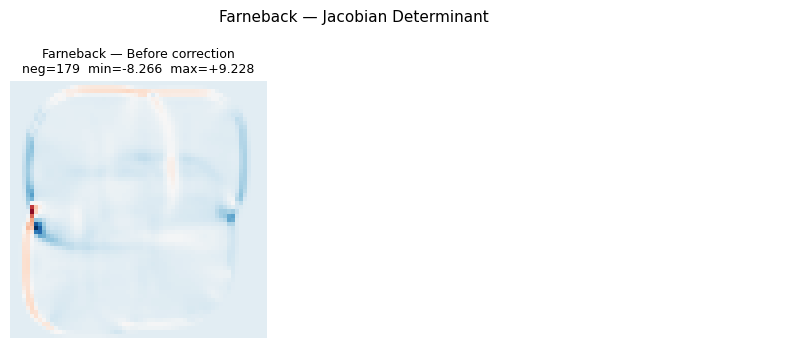

[init] Grid 64x64  |  threshold=0.01  |  method=SLSQP  |  workers=24
[init] Neg-Jdet pixels: 179  |  min Jdet: -8.265801
[iter    1]  parallel  batch=5  neg_pixels=180  windows=34x10,5x39,12x4,3x4,3x3
         -> neg_jdet    39  min_jdet -1.100386  L2 21.0084
[iter    2]  parallel  batch=10  neg_pixels=42  windows=3x4,4x4,4x3,9x6,4x4,4x4,4x3,6x3,6x3,4x4
         -> neg_jdet    32  min_jdet -1.787163  L2 22.0308
[iter    3]  parallel  batch=12  neg_pixels=32  windows=3x3,4x3,3x3,3x3,3x4,4x3,4x3,3x3,3x3,3x3,3x6,3x3
         -> neg_jdet    44  min_jdet -6.143511  L2 21.3984
  [escalate] parallel didn't improve (32->44), global min window -> 5x5
[iter    4]  parallel  batch=9  neg_pixels=45  windows=5x5,5x5,5x5,5x5,7x5,5x5,5x5,5x5,5x5
         -> neg_jdet    44  min_jdet -3.188383  L2 21.0635
  [escalate] parallel didn't improve (44->44), global min window -> 7x7
[iter    5]  parallel  batch=7  neg_pixels=47  windows=7x7,7x7,7x7,7x7,7x7,7x7,7x7
         -> neg_jdet    60  min_jdet -4.99920

KeyboardInterrupt: 

In [5]:
results = {}

if HAS_CV2:
    import cv2

    # Convert to uint8 for OpenCV
    fixed_u8 = (fixed_np * 255).astype(np.uint8)
    moving_u8 = (moving_np * 255).astype(np.uint8)

    t0 = time.perf_counter()
    flow = cv2.calcOpticalFlowFarneback(
        fixed_u8, moving_u8,
        flow=None,
        pyr_scale=0.5,
        levels=5,
        winsize=15,
        iterations=10,
        poly_n=7,
        poly_sigma=1.5,
        flags=0,
    )
    reg_time = time.perf_counter() - t0

    # OpenCV flow: (H, W, 2) with [..., 0]=dx, [..., 1]=dy
    dx = flow[..., 0].astype(np.float64)
    dy = flow[..., 1].astype(np.float64)
    results["Farneback"] = summarize_and_correct(to_dvfopt(dy, dx), "Farneback", reg_time)
else:
    print("OpenCV not available â€” skipping")

## Method 2: TV-L1 Optical Flow

Total-variation L1 dual formulation.  Better edge preservation but
can still produce folding at discontinuities.

In [6]:
HAS_OPTFLOW = HAS_CV2 and hasattr(cv2, "optflow")

if HAS_OPTFLOW:
    tvl1 = cv2.optflow.DualTVL1OpticalFlow_create()
    tvl1.setTau(0.25)
    tvl1.setLambda(0.15)
    tvl1.setTheta(0.3)
    tvl1.setScalesNumber(5)
    tvl1.setWarps(5)

    t0 = time.perf_counter()
    flow = tvl1.calc(fixed_u8, moving_u8, None)
    reg_time = time.perf_counter() - t0

    dx = flow[..., 0].astype(np.float64)
    dy = flow[..., 1].astype(np.float64)
    results["TV-L1"] = summarize_and_correct(to_dvfopt(dy, dx), "TV-L1", reg_time)
else:
    print("TV-L1 skipped — requires opencv-contrib-python (pip install opencv-contrib-python-headless)")


## Method 3: DIS (Dense Inverse Search)

Real-time dense optical flow.  Very fast, but the speed/quality
trade-off means more folding.


  DIS  |  64x64  |  neg Jdet: 0  |  flow time: 0.0041s
  Before: min Jdet=+0.116711  max Jdet=+2.904001
  No folding detected â€” skipping correction.


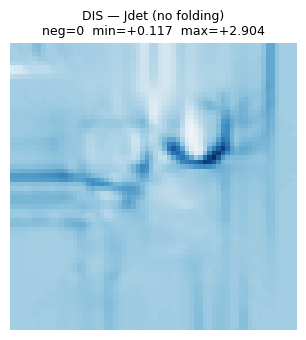

In [7]:
if HAS_CV2:
    dis = cv2.DISOpticalFlow_create(cv2.DISOPTICAL_FLOW_PRESET_MEDIUM)

    t0 = time.perf_counter()
    flow = dis.calc(fixed_u8, moving_u8, None)
    reg_time = time.perf_counter() - t0

    dx = flow[..., 0].astype(np.float64)
    dy = flow[..., 1].astype(np.float64)
    results["DIS"] = summarize_and_correct(to_dvfopt(dy, dx), "DIS", reg_time)
else:
    print("OpenCV not available â€” skipping")

---
## Summary

In [ ]:
if results:
    print(f"{'Method':<12s}  {'Flow (s)':>10s}  {'Neg init':>10s}  {'Neg final':>10s}  "
          f"{'Corr (s)':>10s}  {'L2 Error':>10s}  {'Min Jdet':>10s}")
    print("-" * 80)
    for name, r in results.items():
        print(f"{name:<12s}  {r['reg_time']:>10.4f}  {r['n_neg_init']:>10d}  "
              f"{r['n_neg_final']:>10d}  {r['time']:>10.2f}  "
              f"{r['l2']:>10.4f}  {r['min_jdet']:>+10.6f}")

    # Bar chart
    methods = list(results.keys())
    x = np.arange(len(methods))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    ax = axes[0]
    ax.bar(x - 0.15, [results[m]["n_neg_init"] for m in methods], 0.3,
           label="Before", color="tab:red", alpha=0.7)
    ax.bar(x + 0.15, [results[m]["n_neg_final"] for m in methods], 0.3,
           label="After", color="tab:green", alpha=0.7)
    ax.set_xticks(x); ax.set_xticklabels(methods)
    ax.set_ylabel("Neg Jdet pixels")
    ax.set_title("Folding: Before vs After")
    ax.legend()

    ax = axes[1]
    ax.bar(x - 0.15, [results[m]["reg_time"] for m in methods], 0.3,
           label="Optical flow", color="tab:blue", alpha=0.7)
    ax.bar(x + 0.15, [results[m]["time"] for m in methods], 0.3,
           label="Correction", color="tab:orange", alpha=0.7)
    ax.set_xticks(x); ax.set_xticklabels(methods)
    ax.set_ylabel("Time (s)")
    ax.set_title("Flow vs Correction Time")
    ax.legend()

    ax = axes[2]
    ax.bar(methods, [results[m]["l2"] for m in methods], color="tab:purple", alpha=0.7)
    ax.set_ylabel("L2 Error")
    ax.set_title("Correction L2 Deviation")

    plt.suptitle("OpenCV Optical Flow â€” DVFopt Correction", fontsize=13)
    plt.tight_layout()
    plt.show()